In [1]:
#Purpose
#analysing rising sea level trends in the Pacific and assessing the projected impact on low-lying nations
#The question for this section is that is there a trend of rising sea levels in Tuvalu? 
#Importing Libraries
library(tidyverse)
library(ggplot2)
library(reshape2)

Warning message:
"package 'ggplot2' was built under R version 4.5.3"
── Attaching core tidyverse 
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ───────────────
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'reshape2' was built under R version 4.5.3"

Attaching package: 'reshape2'


The following object is masked from 'package:tidyr':

    smiths




In [2]:
#Importing dataset and inspection
main_df <- read.csv("fixed_cleaned_Tuvalu_sea_level_clean.csv")

In [3]:
summary(main_df)

      Year          Month         Monthly_MSL     Linear_Trend  
 Min.   :1977   Min.   : 1.000   Min.   :6.576   Min.   :6.923  
 1st Qu.:1989   1st Qu.: 3.000   1st Qu.:6.967   1st Qu.:6.967  
 Median :2000   Median : 6.000   Median :7.016   Median :6.992  
 Mean   :2000   Mean   : 6.502   Mean   :7.000   Mean   :6.999  
 3rd Qu.:2011   3rd Qu.:10.000   3rd Qu.:7.055   3rd Qu.:7.035  
 Max.   :2023   Max.   :12.000   Max.   :7.184   Max.   :7.080  
   High_Conf        Low_Conf    
 Min.   :6.961   Min.   :6.886  
 1st Qu.:6.993   1st Qu.:6.940  
 Median :7.016   Median :6.969  
 Mean   :7.028   Mean   :6.971  
 3rd Qu.:7.062   3rd Qu.:7.007  
 Max.   :7.117   Max.   :7.042  

In [4]:
#Step 4 Assume a prior: average sea level rise is between 100–110mm


#Step 4.0.1 Since Monthly_MSL is measured in metres not MM, scaling Monthly_MSL values to mm and creating a new column for it
main_df$Sea_level_mm <- (main_df$Monthly_MSL -  min(main_df$Monthly_MSL)) * 1000

print(summary(main_df$Sea_level_mm)) #Verifying if column exists and is correct
print(range(main_df$Sea_level_mm)) #verifying new range

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    0.0   390.8   440.0   423.5   479.0   608.0 
[1]   0 608


In [5]:
#Result 0mm-608mm; sea level has risen ~608mm from 1977 to 2023

#Step 4.0.2 Converting Prior Thresholds to proportions
#Beta distributions only accept values on 0-1 scale
lower_prop <- 100 / 608   # = 0.164 → 100mm is ~16.4% of the full range
upper_prop <- 110 / 608   # = 0.181 → 110mm is ~18.1% of the full range
mid_prop   <- 105 / 608   # = 0.173 → midpoint of our prior belief

print(lower_prop * 100)
print(upper_prop * 100)
print(mid_prop * 100)

[1] 16.44737
[1] 18.09211
[1] 17.26974


In [6]:
#Step 4.0.3 Finding Beta Parameters
#mean = alpha / ( alpha + beta)
#Want the mean to equal to our midpoint porportion 0.17 
# If I try α = 2, β = 10:
#   mean = 2 / (2 + 10) = 2/12 = 0.167 ✅ close to 0.17

alpha_prior <- 2
beta_prior <- 10

In [7]:
#Step 4.1.0 Model with a Beta prior and update with observed data (e.g., number of years > 110mm)

#Step 4.1.1 Calculating the successes and failures of where months exceed or not the sea levels
successes <- sum(main_df$Sea_level_mm > 110) #The count of months that observed sea levels going over 110mm
failures <- sum(main_df$Sea_level_mm <= 110) #The count of months that observed sea levels did NOT exceed 110mm

print(successes)
print(failures)

[1] 512
[1] 8


In [8]:
#Step 4.1.2 Updating prior with observed data
#Posterior = Beta(α_prior + successes, β_prior + failures)
alpha_post <- alpha_prior + successes 
beta_post  <- beta_prior + failures   

print(alpha_post) 
print(beta_post) 
#the posterior parameters reflect the dominance of observed exceedances, 
#shifting the prior belief substantially towards a high probability of exceeding 110mm

[1] 514
[1] 18


In [9]:
#Step 4.2.0 Simulate 10,000 posterior samples using rbeta()
#Step 4.2.1 Simulation using rbeta()
posterior <- rbeta(10000, alpha_post, beta_post)
summary(posterior)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.9320  0.9611  0.9666  0.9661  0.9718  0.9881 

In [10]:
#Step 4.3.0 Estimate the probability that true average > 115mm
#Converting 115mm to proportion of observed range (0-608mm)
threshold_115 <- 115/608
print(threshold_115) 

[1] 0.1891447


In [11]:
# Calculate proportion of posterior samples exceeding this threshold
prob_above_115 <- mean(posterior > threshold_115)
print(prob_above_115)

[1] 1


In [12]:
#Based on the observed Tuvalu sea level data and Bayesian updating, 
#there is effectively a 100% probability that the true average sea level exceeds 115mm above the 1977 baseline.

In [13]:
# the result of exactly 1 doesn't mean literally 100% certainty in a philosophical sense. 
#It means none of your 10,000 simulated samples fell below the threshold, 
#which reflects the overwhelming strength of the evidence.

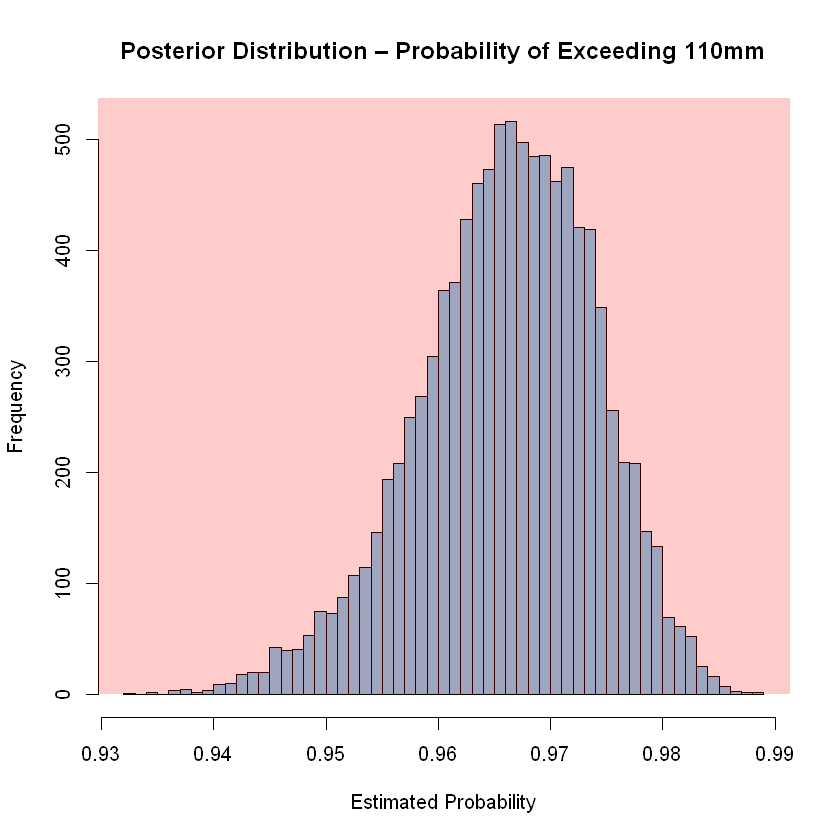

In [19]:
#Step 4.2.2 Visual distribution of all 10,000 samples and  decision boundary
# hist() shows the spread of 10,000 simulated posterior samples

hist(posterior,
     breaks = 50,              # more breaks = finer detail
     col    = "skyblue",
     main   = "Posterior Distribution – Probability of Exceeding 110mm",
     xlab   = "Estimated Probability")

# Shaded region to the right of threshold (exceedance zone)
rect(xleft   = threshold_115,  # starts at 0.189 (off screen due to xlim)
     ybottom = 0,
     xright  = 1,
     ytop    = 7000,
     col     = rgb(1, 0, 0, alpha = 0.2),  # transparent red
     border  = NA)

# Note: The decision boundary (threshold_115 = 0.189) is not visible
# on this plot as it falls far outside the posterior distribution range